# Data Challenge 10 — MLR Interpretation with Adjusted R² (HVFHV Trips)


**Format:** Instructor Guidance → You Do (Students) → We Share (Reflection)

**Goal:** Build **3 MLR models** with different feature sets to predict a numeric target, then compare **Adjusted R²** and **p-values** to select the better model and justify it in business terms.

**Data:** July 1, 2023 - July 15, 2023 For Hire Vehicle Data in NYC

[July For Hire Vehicles Data](https://data.cityofnewyork.us/Transportation/2023-High-Volume-FHV-Trip-Data/u253-aew4/about_data)


## Instructor Guidance

**Hint: Use the Lecture Deck, Canvas Reading, and Docs to help you with the code**

Use this guide live; students implement below.

**Docs (quick links):**
- TLC HVFHV data dictionary (columns/meaning): https://www.nyc.gov/assets/tlc/downloads/pdf/data_dictionary_trip_records_hvfhs.pdf  
- statsmodels OLS: https://www.statsmodels.org/stable/generated/statsmodels.regression.linear_model.OLS.html  
- OLS Results (attributes like `rsquared_adj`, `pvalues`): https://www.statsmodels.org/stable/generated/statsmodels.regression.linear_model.RegressionResults.html  

### Pseudocode Plan
1) **Load CSV** → preview columns/shape; confirm target & candidate predictors exist.  
2) **Assign Y + Xs** (start small, add features with a hypothesis). Coerce **just these columns** to numeric.  
3) **Light prep:** derive `trip_time_minutes` from `trip_time` (seconds); convert flags (`shared_request_flag`, `wav_request_flag`) to 0/1 if present.  
4) **Model sets (3 total):**  
   - **Model A (parsimonious).**  
   - **Model B (adds one meaningful predictor).**  
   - **Model C (adds 1–2 more, e.g., flags).  
5) **Add intercept** and **fit** each with OLS on the same rows.  
6) **Record metrics:** `rsquared_adj`, coefficient table, and **p-values**.  
7) **Compare:** Prefer higher **Adjusted R²** and keep an eye on **p-values** (and signs/units).  
8) **Interpretation:** Write unit-based sentences **holding others constant**.  
9) **Selection rationale:** Pick the simplest model that improves **Adjusted R²** and 


## You Do — Student Section
Work in pairs. Comment your choices briefly. Keep code simple—only coerce the columns you use.

### Step 0 — Setup & Imports

In [95]:
import pandas as pd, numpy as np
import statsmodels.api as sm
from pathlib import Path
from sklearn.model_selection import train_test_split


pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

### Step 1 — Load CSV & Preview
- Point to your For Hire Vehicle Data 
- Print **shape** and **columns**.

**Hint: You may have to drop missing values and do a force coercion to make sure the variables stay numeric (other coding assignments may help)**

In [128]:
df = pd.read_csv('/Users/beans/Desktop/FHV_072023 copy.csv',nrows=1000000)

/var/folders/3y/ldxff8k17wjcyzkq19xw1srm0000gn/T/ipykernel_937/3001244395.py:1: DtypeWarning: Columns (11,18) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/Users/beans/Desktop/FHV_072023 copy.csv',nrows=1000000)


In [129]:
display(df.info())
display(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 24 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   hvfhs_license_num     1000000 non-null  object 
 1   dispatching_base_num  1000000 non-null  object 
 2   originating_base_num  708802 non-null   object 
 3   request_datetime      1000000 non-null  object 
 4   on_scene_datetime     708802 non-null   object 
 5   pickup_datetime       1000000 non-null  object 
 6   dropoff_datetime      1000000 non-null  object 
 7   PULocationID          1000000 non-null  int64  
 8   DOLocationID          1000000 non-null  int64  
 9   trip_miles            1000000 non-null  float64
 10  trip_time             1000000 non-null  object 
 11  base_passenger_fare   1000000 non-null  object 
 12  tolls                 1000000 non-null  float64
 13  bcf                   1000000 non-null  float64
 14  sales_tax             1000000 non-n

None

,hvfhs_license_num,dispatching_base_num,originating_base_num,request_datetime,on_scene_datetime,pickup_datetime,dropoff_datetime,PULocationID,DOLocationID,trip_miles,...,sales_tax,congestion_surcharge,airport_fee,tips,driver_pay,shared_request_flag,shared_match_flag,access_a_ride_flag,wav_request_flag,wav_match_flag
0,HV0005,B03406,NaN,07/01/2023 05:34:30 PM,NaN,07/01/2023 05:37:48 PM,07/01/2023 05:44:45 PM,158,68,1.2660,...,1.3500,2.7500,0.0000,2.0000,5.5700,N,N,N,N,False
1,HV0003,B03404,B03404,07/01/2023 05:34:30 PM,07/01/2023 05:36:53 PM,07/01/2023 05:37:15 PM,07/01/2023 05:55:15 PM,162,234,2.3500,...,1.5200,2.7500,0.0000,3.2800,13.3800,N,N,NaN,N,False
2,HV0003,B03404,B03404,07/01/2023 05:34:30 PM,07/01/2023 05:35:17 PM,07/01/2023 05:35:52 PM,07/01/2023 05:44:27 PM,161,163,0.8100,...,0.4900,2.7500,0.0000,0.0000,5.9500,N,N,NaN,N,False
3,HV0003,B03404,B03404,07/01/2023 05:34:30 PM,07/01/2023 05:37:39 PM,07/01/2023 05:39:35 PM,07/01/2023 06:23:02 PM,122,229,15.4700,...,5.1700,2.7500,0.0000,0.0000,54.4600,N,N,NaN,N,True
4,HV0003,B03404,B03404,07/01/2023 05:34:30 PM,07/01/2023 05:36:06 PM,07/01/2023 05:36:39 PM,07/01/2023 05:45:06 PM,67,14,1.5200,...,0.8500,0.0000,0.0000,3.0000,7.0100,N,N,NaN,N,False


In [130]:
# creating bool from shared_request_flag

booleans = []
for i in range(len(df)):
    if df.iloc[i]['shared_request_flag'] == 'N':
        booleans.append(0)
    else:
        booleans.append(1)

booleans

df['shared_request_bool'] = booleans


### Step 2 —  Choose Target **Y** and Candidate Predictors

- Suggested **Y**: `base_passenger_fare` (USD).
- Start with **distance** and **time**; optionally add **flags** if present.
- Derive `trip_time_minutes` from `trip_time` (seconds) if available.

In [131]:
# Coerce fare, distance to numeric safely
num_cols = ['trip_time', 'base_passenger_fare','trip_miles']
for c in num_cols:
    df[c] = pd.to_numeric(
        df[c].astype(str).str.strip().str.replace(r'[^0-9.+\-eE]', '', regex=True),
        errors='coerce'
)
    
# Clean data some by removing values less than 0 and dropping NAN values
df = df[(df['trip_time'] >= 0) & (df['base_passenger_fare'] > 0) & (df['trip_miles'] > 0)]
df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=num_cols)

In [132]:
# creating minutes feature from trip time (in seconds)
df['trip_time_minutes'] = df['trip_time'] / 60
df['trip_time_minutes']

0         6.9500
1        18.0000
2         8.5833
3        43.4500
4         8.4500
           ...  
999995   24.6333
999996   19.3833
999997    9.9333
999998   14.5333
999999    6.4833
Name: trip_time_minutes, Length: 999811, dtype: float64

In [133]:
# choosing trip_time minutes to be greater than 5 minutes, as although there are many rides less than 5 minutes, it will not be meaningful
# for an analysis to focus on. also choosing percentiles less than 99.999 to remove significantly high values as they are not as frequent and can skew
# analysis
df = df[(df['trip_time_minutes'] <= np.percentile(df['trip_time_minutes'],99.999)) & (df['trip_time_minutes'] > 5)]

# removing passenger fares that are above 99.999 percentile, as there are higher values that aren't as representative of the data
df = df[df['base_passenger_fare'] <= np.percentile(df['base_passenger_fare'],99.999)]

#last filter rows = 3055093
#increased the value of percentile as it was removing too many larger values if i did 0.9999
df = df[df['trip_miles'] <= np.percentile(df['trip_miles'],99.999)]

<Axes: xlabel='trip_time_minutes', ylabel='base_passenger_fare'>

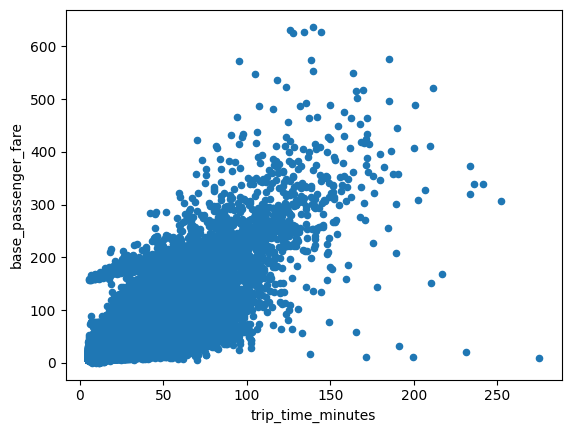

In [134]:
df.plot(kind='scatter',x='trip_time_minutes',y='base_passenger_fare')

<Axes: xlabel='trip_miles', ylabel='base_passenger_fare'>

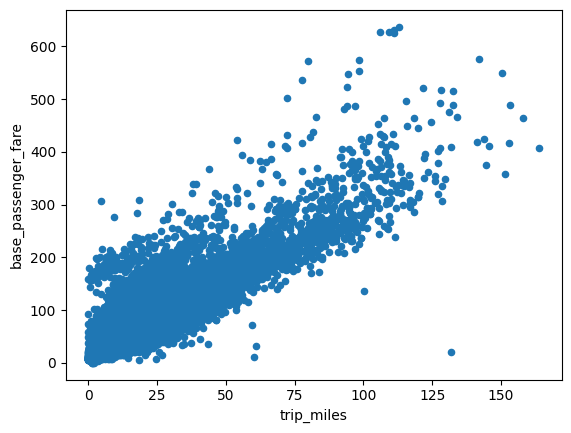

In [135]:
df.plot(kind='scatter',x='trip_miles',y='base_passenger_fare')

In [136]:
modeldata = df[['base_passenger_fare','trip_miles','trip_time_minutes','shared_request_bool']]

y = modeldata['base_passenger_fare']
xone = modeldata['trip_time_minutes']
xtwo = modeldata['trip_miles']
xthree = modeldata['shared_request_bool']

### Step 3 — Define Three Model Specs (A, B, C)
Example models you can chose any models you want as long as Model A has one term, Model B two terms, etc.

- **Model A:** distance only.  
- **Model B:** distance + time (minutes).  
- **Model C:** distance + time + flags (whichever exist).

In [137]:
# MODEL A (SLR distance only)

X_one = sm.add_constant(df['trip_time_minutes'])

np.random.seed(10)
Xone_train, Xone_test, yone_train, yone_test = train_test_split(X_one, y, test_size=0.2, random_state=10)

print(f"X Training data shape: {Xone_train.shape}")
print(f"X Testing data shape:  {Xone_test.shape}")
print(f"Y Training data shape: {yone_train.shape}")
print(f"Y Testing data shape:  {yone_test.shape}")

modela = sm.OLS(yone_train, Xone_train).fit()
modela.summary()


X Training data shape: (760400, 2)
X Testing data shape:  (190100, 2)
Y Training data shape: (760400,)
Y Testing data shape:  (190100,)


<class 'statsmodels.iolib.summary.Summary'>
"""
                             OLS Regression Results                            
===============================================================================
Dep. Variable:     base_passenger_fare   R-squared:                       0.684
Model:                             OLS   Adj. R-squared:                  0.684
Method:                  Least Squares   F-statistic:                 1.646e+06
Date:                 Wed, 05 Nov 2025   Prob (F-statistic):               0.00
Time:                         15:59:30   Log-Likelihood:            -2.8928e+06
No. Observations:               760400   AIC:                         5.786e+06
Df Residuals:                   760398   BIC:                         5.786e+06
Df Model:                            1                                         
Covariance Type:             nonrobust                                         
=====================================================================================
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -2.2610      0.024    -94.927      0.000      -2.308      -2.214
trip_time_minutes     1.4229      0.001   1283.157      0.000       1.421       1.425
==============================================================================
Omnibus:                   790901.472   Durbin-Watson:                   1.998
Prob(Omnibus):                  0.000   Jarque-Bera (JB):        211284196.358
Skew:                           4.704   Prob(JB):                         0.00
Kurtosis:                      84.118   Cond. No.                         41.1
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [138]:
# MODEL B (MLR distance + time)

X_two = sm.add_constant(df[['trip_time_minutes', 'trip_miles']])

np.random.seed(10)
Xtwo_train, Xtwo_test, ytwo_train, ytwo_test = train_test_split(X_two, y, test_size=0.2, random_state=10)

print(f"X Training data shape: {Xtwo_train.shape}")
print(f"X Testing data shape:  {Xtwo_test.shape}")
print(f"Y Training data shape: {ytwo_train.shape}")
print(f"Y Testing data shape:  {ytwo_test.shape}")


X Training data shape: (760400, 3)
X Testing data shape:  (190100, 3)
Y Training data shape: (760400,)
Y Testing data shape:  (190100,)


In [139]:
# MODEL B (MLR distance + time)

X_three = sm.add_constant(df[['trip_time_minutes', 'trip_miles','shared_request_bool']])

np.random.seed(10)
Xthree_train, Xthree_test, ythree_train, ythree_test = train_test_split(X_three, y, test_size=0.2, random_state=10)

print(f"X Training data shape: {Xthree_train.shape}")
print(f"X Testing data shape:  {Xthree_test.shape}")
print(f"Y Training data shape: {ythree_train.shape}")
print(f"Y Testing data shape:  {ythree_test.shape}")

X Training data shape: (760400, 4)
X Testing data shape:  (190100, 4)
Y Training data shape: (760400,)
Y Testing data shape:  (190100,)


### Step 4 — Fit Each Model (with intercept) and Collect Adjusted R² & p-values


In [ ]:
modela = sm.OLS(yone_train, Xone_train).fit()
print('Const P-Value:',modela.pvalues['const'],'\ntrip_time_minutes p-value:',modela.pvalues['trip_time_minutes'], '\nr_squared:',round(modela.rsquared_adj,3))

Const P-Value: 0.0 
trip_time_minutes p-value: 0.0 
r_squared: 0.684


In [168]:
modelb = sm.OLS(ytwo_train, Xtwo_train).fit()
print('Const P-Value:',modelb.pvalues['const'],'\ntrip_time_minutes p-value:',modelb.pvalues['trip_time_minutes'],'\ntrip_miles p-value',modelb.pvalues['trip_miles'], '\nr_squared:',round(modelb.rsquared_adj,3))

Const P-Value: 0.0 
trip_time_minutes p-value: 0.0 
trip_miles p-value 0.0 
r_squared: 0.824


In [173]:
modelc = sm.OLS(ythree_train, Xthree_train).fit()
print('const P-Value:',modelc.pvalues['const'],'\ntrip_time_minutes p-value:',modelc.pvalues['trip_time_minutes'],'\ntrip_miles p-value',modelc.pvalues['trip_miles'], '\nshared_request_bool p-value:',modelc.pvalues['shared_request_bool'], '\nr_squared:',round(modelc.rsquared_adj,3))

const P-Value: 0.0 
trip_time_minutes p-value: 0.0 
trip_miles p-value 0.0 
shared_request_bool p-value: 0.0 
r_squared: 0.827


### Step 5 — Inspect Full Summaries (coefficients, p-values, diagnostics)

- Print summaries for the top 1–2 models by **Adjusted R²**.
- Write **unit-based** interpretations “holding others constant.”

In [179]:
modela.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                             OLS Regression Results                            
===============================================================================
Dep. Variable:     base_passenger_fare   R-squared:                       0.684
Model:                             OLS   Adj. R-squared:                  0.684
Method:                  Least Squares   F-statistic:                 1.646e+06
Date:                 Wed, 05 Nov 2025   Prob (F-statistic):               0.00
Time:                         22:23:23   Log-Likelihood:            -2.8928e+06
No. Observations:               760400   AIC:                         5.786e+06
Df Residuals:                   760398   BIC:                         5.786e+06
Df Model:                            1                                         
Covariance Type:             nonrobust                                         
=====================================================================================
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -2.2610      0.024    -94.927      0.000      -2.308      -2.214
trip_time_minutes     1.4229      0.001   1283.157      0.000       1.421       1.425
==============================================================================
Omnibus:                   790901.472   Durbin-Watson:                   1.998
Prob(Omnibus):                  0.000   Jarque-Bera (JB):        211284196.358
Skew:                           4.704   Prob(JB):                         0.00
Kurtosis:                      84.118   Cond. No.                         41.1
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

- If your trip_time in minutes was 0, you'd lose $2.26. Per each minute increase in trip time, your base_passenger_fare increases by $1.42.

In [176]:
modelb.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                             OLS Regression Results                            
===============================================================================
Dep. Variable:     base_passenger_fare   R-squared:                       0.824
Model:                             OLS   Adj. R-squared:                  0.824
Method:                  Least Squares   F-statistic:                 1.784e+06
Date:                 Wed, 05 Nov 2025   Prob (F-statistic):               0.00
Time:                         21:47:58   Log-Likelihood:            -2.6698e+06
No. Observations:               760400   AIC:                         5.340e+06
Df Residuals:                   760397   BIC:                         5.340e+06
Df Model:                            2                                         
Covariance Type:             nonrobust                                         
=====================================================================================
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 3.3782      0.019    176.118      0.000       3.341       3.416
trip_time_minutes     0.4619      0.001    310.983      0.000       0.459       0.465
trip_miles            2.1992      0.003    778.982      0.000       2.194       2.205
==============================================================================
Omnibus:                   848168.652   Durbin-Watson:                   1.999
Prob(Omnibus):                  0.000   Jarque-Bera (JB):        280043444.953
Skew:                           5.283   Prob(JB):                         0.00
Kurtosis:                      96.419   Cond. No.                         47.0
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

- As your trip_time_minutes increase, you'd gain 46 cents per minute holding trip_miles constant.
- As your trip_miles increase, you'd gain $2.19 per mile holding trip_time_minutes constant.

### Step 6 — Interpretations (write below)

Using the **best model’s** coefficients interpret each coefficient using markdown

In [177]:
modelc.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                             OLS Regression Results                            
===============================================================================
Dep. Variable:     base_passenger_fare   R-squared:                       0.827
Model:                             OLS   Adj. R-squared:                  0.827
Method:                  Least Squares   F-statistic:                 1.213e+06
Date:                 Wed, 05 Nov 2025   Prob (F-statistic):               0.00
Time:                         21:48:09   Log-Likelihood:            -2.6636e+06
No. Observations:               760400   AIC:                         5.327e+06
Df Residuals:                   760396   BIC:                         5.327e+06
Df Model:                            3                                         
Covariance Type:             nonrobust                                         
=======================================================================================
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   3.4632      0.019    181.868      0.000       3.426       3.501
trip_time_minutes       0.4679      0.001    317.361      0.000       0.465       0.471
trip_miles              2.1928      0.003    782.858      0.000       2.187       2.198
shared_request_bool    -6.7414      0.061   -111.283      0.000      -6.860      -6.623
==============================================================================
Omnibus:                   859901.335   Durbin-Watson:                   1.999
Prob(Omnibus):                  0.000   Jarque-Bera (JB):        295603406.159
Skew:                           5.408   Prob(JB):                         0.00
Kurtosis:                      98.984   Cond. No.                         149.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

The best model, which is Model C, uses both trip_time_minutes, trip_miles, and shared_request_bool columns which states:

- When trip_time_minutes, trip_miles, and shared_request_bool is equal to 0, the driver will earn $3.46.
- As trip_time_minutes increase, your base_passenger_fare increases by 46 cents, holding trip_miles and shared_request constant.
- As trip_miles increase, your base_passenger_fare increases by $2.19, holding trip_time_minutes and shared_request constant.
- If the ride includes a shared request, your base_passenger_fare reduces by $6.74 cents, holding trip_time_minutes and trip_miles constant.

## We Share — Reflection & Wrap‑Up

Write **2 short paragraphs** and be specific:

1) **Which model (A/B/C) do you pick and why?**  
Reference **Adjusted R²** (higher is better when comparing models with different numbers of predictors) and the **p-values**/signs of key coefficients.

I would pick Model C as it has the highest Adjusted R² value (0.827), representing higher predictability compared to the other two models (B: 0.824, A:0.684). Including more features to our model allowed for better prediction in our model, as the value of R² did not reduce, which would've happened if the features introduced overfitting or unreliability.

2) **Business explanation:**  
Give a stakeholder-friendly summary in **units** (e.g., “+1 mile ≈ +$X in base fare, holding time constant”). If you added flags, explain their effect plainly. Mention any limitations (e.g., time vs distance confounding, missing columns).

The best model, which is Model C, uses both trip_time_minutes, trip_miles, and shared_request_bool columns which states:

- When the ride is at 0 minutes, the trip has no miles, and the ride is not shared, the driver will earn $3.46.
- As your trip time minutes increase, your base passenger fare increases by 46 cents, when holding trip_miles and shared_request constant.
- As the miles on the trip increases, your base passenger fare increases by $2.19, when holding trip_time_minutes and shared_request constant.
- If the ride includes a shared request, your base passenger fare reduces by $6.74, when holding trip_time_minutes and trip_miles constant.